In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

bash: ../xvfb: No such file or directory


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!pip3 install -q gymnasium[classic-control]

## Семинар: Q-learning (1,5 балла)

В этой тетради вы узнаете, как реализовать простой алгоритм Q-learning.

Вам необходимо внедрить Q Learning Agent (следуйте инструкциям для каждого метода) и использовать его в ряде тестов, приведенных ниже.

In [5]:
from collections import defaultdict
import random
import math
import numpy as np


class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        """
        Q-Learning Agent
        based on https://inst.eecs.berkeley.edu/~cs188/sp19/projects.html
        Instance variables you have access to
          - self.epsilon (exploration prob)
          - self.alpha (learning rate)
          - self.discount (discount rate aka gamma)

        Functions you should use
          - self.get_legal_actions(state) {state, hashable -> list of actions, each is hashable}
            which returns legal actions for a state
          - self.get_qvalue(state,action)
            which returns Q(state,action)
          - self.set_qvalue(state,action,value)
            which sets Q(state,action) := value
        !!!Important!!!
        Note: please avoid using self._qValues directly. 
            There's a special self.get_qvalue/set_qvalue for that.
        """

        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        """ Returns Q(state,action) """
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        """ Sets the Qvalue for [state,action] to the given value """
        self._qvalues[state][action] = value

    #---------------------START OF YOUR CODE---------------------#

    def get_value(self, state):
        """
        Compute your agent's estimate of V(s) using current q-values
        V(s) = max_over_action Q(state,action) over possible actions.
        Note: please take into account that q-values can be negative.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        value = max([self.get_qvalue(state, action) for action in possible_actions])

        return value

    def update(self, state, action, reward, next_state):
        """
        You should do your Q-Value update here:
           Q(s,a) := (1 - alpha) * Q(s,a) + alpha * (r + gamma * V(s'))
        """

        # agent parameters
        gamma = self.discount
        learning_rate = self.alpha

        current_q = self.get_qvalue(state, action)
        next_state_value = self.get_value(next_state)
        new_q = (1 - learning_rate) * current_q + learning_rate * (reward + gamma * next_state_value)

        self.set_qvalue(state, action, new_q)

    def get_best_action(self, state):
        """
        Compute the best action to take in a state (using current q-values). 
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        best_action = max(possible_actions, key=lambda action: self.get_qvalue(state, action))

        return best_action

    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.  
        With probability self.epsilon, we should take a random action.
            otherwise - the best policy action (self.get_best_action).

        Note: To pick randomly from a list, use random.choice(list). 
              To pick True or False with a given probablity, generate uniform number in [0, 1]
              and compare it with your probability
        """

        # Pick Action
        possible_actions = self.get_legal_actions(state)
        action = None

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        # agent parameters:
        epsilon = self.epsilon

        if random.random() < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)

        return chosen_action

### Попробуйте это в taxi

Здесь мы используем Q-Learning agent в среде Taxi-v3 от OpenAI gym.
Вам нужно будет выполнить несколько его функций.

In [6]:
import gymnasium as gym
env = gym.make("Taxi-v3", render_mode='rgb_array')

n_actions = env.action_space.n

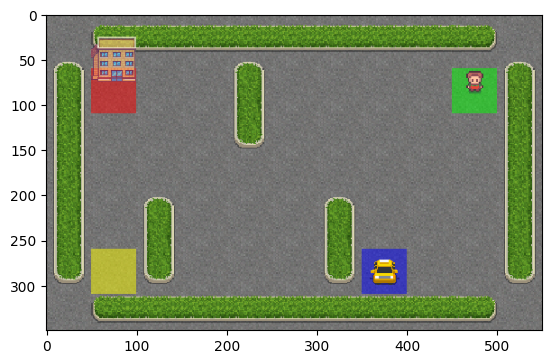

In [8]:
s, _ = env.reset()
plt.imshow(env.render())
pass

In [9]:
agent = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99,
    get_legal_actions=lambda s: range(n_actions))

In [10]:
def play_and_train(env, agent, t_max=10**4):
    """
    This function should 
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s.
        a = agent.get_action(s)

        next_s, r, done, _, _ = env.step(a)

        # train (update) agent for state s
        agent.update(s, a, r, next_s)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

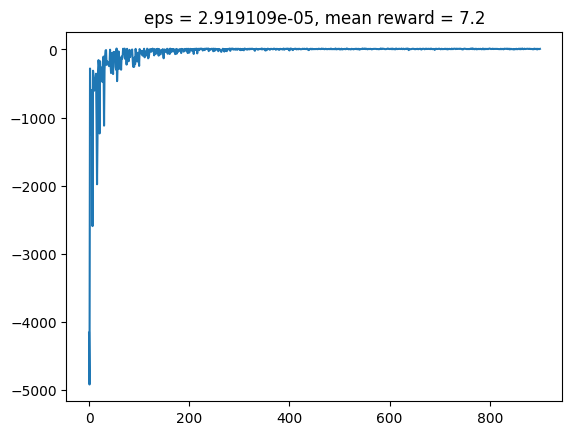

In [11]:
from IPython.display import clear_output

rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        plt.title('eps = {:e}, mean reward = {:.1f}'.format(agent.epsilon, np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.show()

# Семинар: Дискретизированные пространства состояний (1,5 балла)

Используйте agent для эффективного обучения на `Cart Pole-v0`. В этой среде есть непрерывный набор возможных состояний, поэтому вам придется как-то сгруппировать их по ячейкам.

Самый простой способ - использовать "round(x, n_значений)" (или "np.round"), чтобы округлить действительное число до заданного количества цифр. Сложность заключается в том, чтобы правильно подобрать "n_значений" для каждого состояния, чтобы эффективно тренироваться.

Обратите внимание, что вам нужно преобразовать состояние не в целые числа, а в __кортежи__ любых значений.

first state: [ 0.00922456 -0.03244425 -0.03161572  0.04219042]


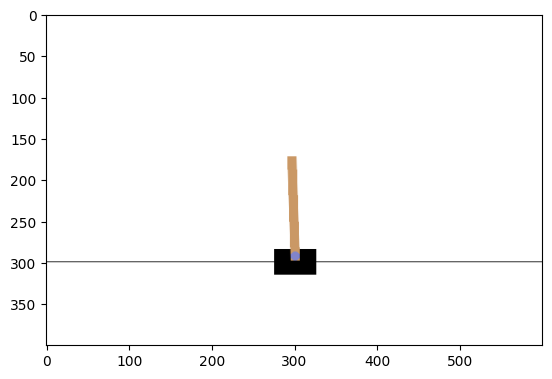

In [13]:
def make_env():
    return gym.make('CartPole-v0', render_mode='rgb_array').env  # .env unwraps the TimeLimit wrapper

env = make_env()
n_actions = env.action_space.n

print("first state: %s" % (env.reset()[0]))
plt.imshow(env.render())
pass

### Сыграем в несколько игр

Нам нужно оценить распределение наблюдений. Для этого мы сыграем в несколько игр и запишем все состояния.

In [14]:
def visualize_cartpole_observation_distribution(seen_observations):
    seen_observations = np.array(seen_observations)
    
    # The meaning of the observations is documented in
    # https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

    f, axarr = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
    for i, title in enumerate(['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Velocity At Tip']):
        ax = axarr[i // 2, i % 2]
        ax.hist(seen_observations[:, i], bins=20)
        ax.set_title(title)
        xmin, xmax = ax.get_xlim()
        ax.set_xlim(min(xmin, -xmax), max(-xmin, xmax))
        ax.grid()
    f.tight_layout()

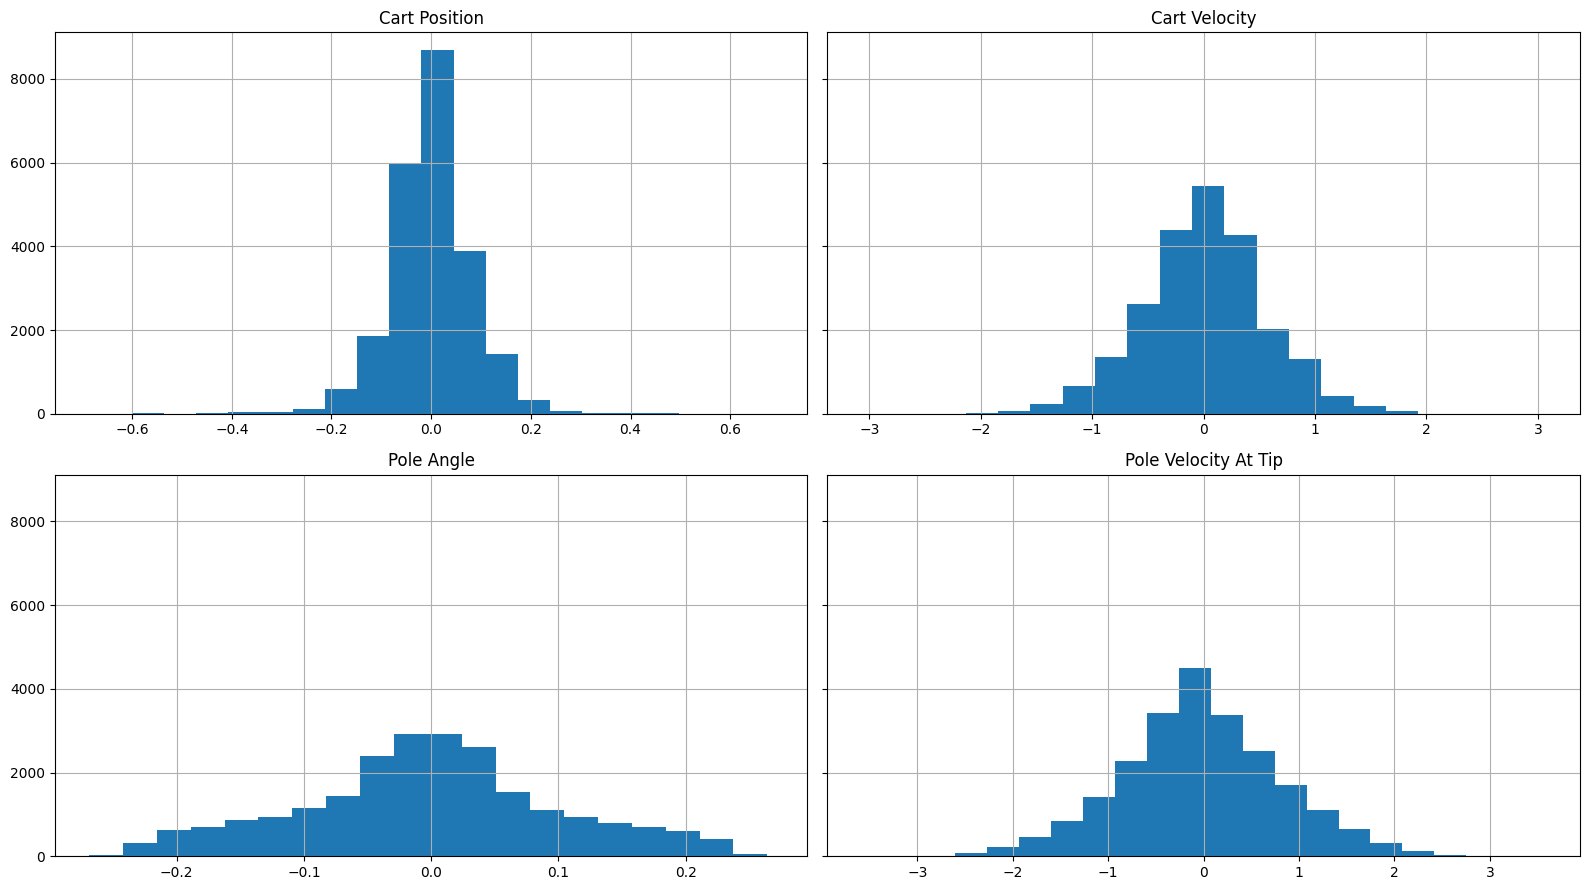

In [15]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)
        
visualize_cartpole_observation_distribution(seen_observations)

## Дискретизированная среда

In [16]:
from gymnasium.core import ObservationWrapper


class Discretizer(ObservationWrapper):
    def observation(self, state):
        # Hint: you can do that with round(x, n_digits).
        # You may pick a different n_digits for each dimension.
        state = [
            round(state[0], 1),
            round(state[1], 1),
            round(state[2], 1),
            round(state[3], 1)
        ]

        return tuple(state)

In [17]:
env = Discretizer(make_env())

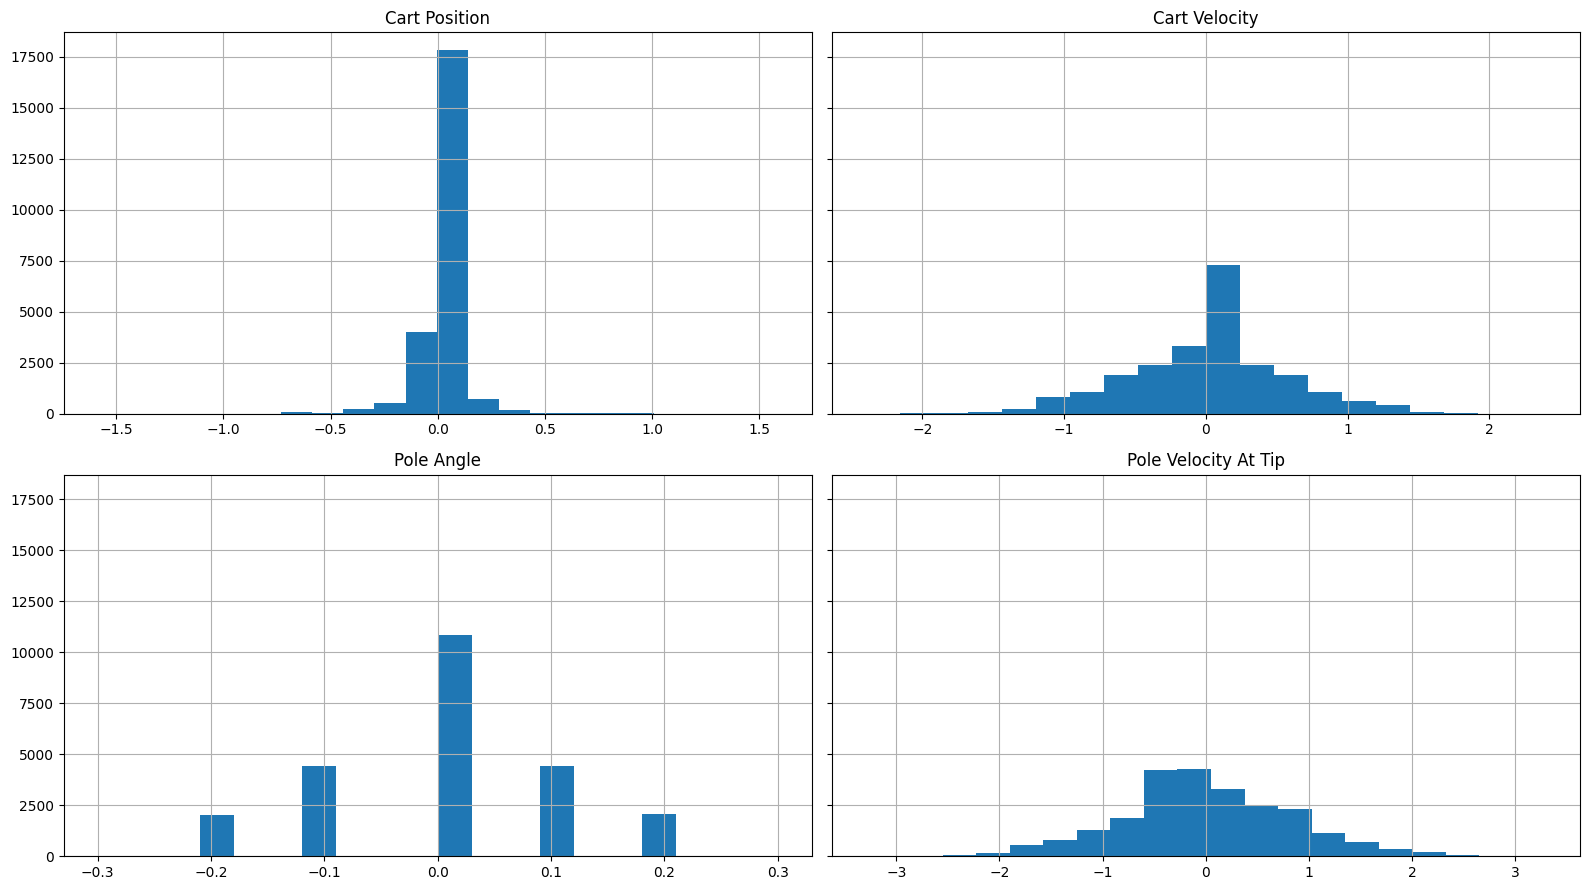

In [18]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)
        if done:
            break
        
visualize_cartpole_observation_distribution(seen_observations)

## Изучите дискретизированную политику

Теперь давайте разработаем политику, которая использует дискретизированное пространство состояний.

__Tips:__

* Обратите внимание, что увеличение количества цифр для одного измерения наблюдений увеличивает ваше пространство состояний в 10 раз.
* Если ваша дискретизация слишком мелкозернистая, вашему агенту потребуется гораздо больше времени, чем 10000 шагов для сходимости. Вы можете либо увеличить количество итераций и уменьшить затухание эпсилон, либо изменить дискретизацию. На практике мы обнаружили, что такого рода ошибки встречаются довольно часто.
* Если ваша дискретизация слишком грубая, ваш агент может не суметь найти оптимальную политику. На практике мы обнаружили, что в данной конкретной среде такого рода ошибки случаются редко.
* ** Начните с грубой дискретизации ** и сделайте ее более детализированной, если это кажется необходимым.
* Рекомендуется использовать $10^3$–$10^4$ различные состояния (`len(agent._qvalues)`), но не обязательно.
* Если что-то не получается без отжига $\varepsilon$, подумайте о том, чтобы добавить это, но убедитесь, что оно не обнулится слишком быстро.

Разумный агент должен получать среднее вознаграждение не менее 50.

In [19]:
import pandas as pd

def moving_average(x, span=100):
    return pd.DataFrame({'x': np.asarray(x)}).x.ewm(span=span).mean().values

In [20]:
agent = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99,
    get_legal_actions=lambda s: range(n_actions))

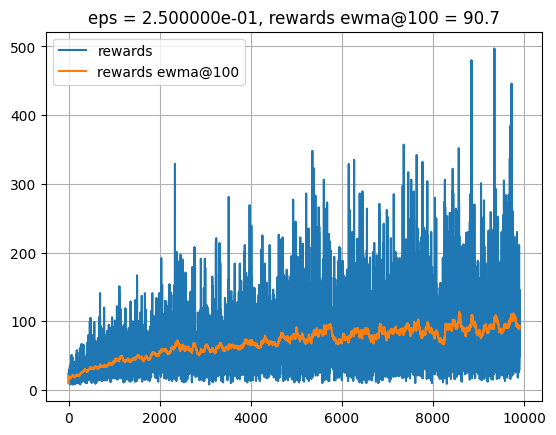

In [21]:
rewards = []
epsilons = []

for i in range(10000):
    reward = play_and_train(env, agent)
    rewards.append(reward)
    epsilons.append(agent.epsilon)
    
    # OPTIONAL: <YOUR CODE: adjust epsilon>

    if i % 100 == 0:
        rewards_ewma = moving_average(rewards)
        
        clear_output(True)
        plt.plot(rewards, label='rewards')
        plt.plot(rewards_ewma, label='rewards ewma@100')
        plt.legend()
        plt.grid()
        plt.title('eps = {:e}, rewards ewma@100 = {:.1f}'.format(agent.epsilon, rewards_ewma[-1]))
        plt.show()

In [22]:
print('Your agent has learned {} Q-values.'.format(len(agent._qvalues)))

Your agent has learned 12045 Q-values.


## Домашнее задание, часть I: Обучение на основе политики и SARSA (3 балла)

Политика, которую мы собираемся использовать, - это эпсилон-жадная политика, при которой агент выполняет оптимальное действие с вероятностью $ (1-\epsilon)$, в противном случае выборка действий производится случайным образом. Обратите внимание, что агент __ может __ время от времени пробовать оптимальные действия во время случайной выборки по чистой случайности.

Теперь мы собираемся внедрить SARSA с ожидаемым значением поверх всего этого.

In [23]:
class EVSarsaAgent(QLearningAgent):
    """ 
    An agent that changes some of q-learning functions to implement Expected Value SARSA. 
    Note: this demo assumes that your implementation of QLearningAgent.update uses get_value(next_state).
    If it doesn't, please add
        def update(self, state, action, reward, next_state):
            and implement it for Expected Value SARSA's V(s')
    """

    def get_value(self, state):
        """ 
        Returns Vpi for current state under epsilon-greedy policy:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Hint: all other methods from QLearningAgent are still accessible.
        """
        epsilon = self.epsilon
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        best_action = self.get_best_action(state)
        best_q_value = self.get_qvalue(state, best_action)

        n_actions = len(possible_actions)
        state_value = 0.0
        
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            if action == best_action:
                action_prob = (1 - epsilon) + epsilon / n_actions
            else:
                action_prob = epsilon / n_actions
            
            state_value += action_prob * q_value

        return state_value

### Cliff World

Давайте теперь посмотрим, как наш алгоритм соотносится с q-обучением в случае, когда мы заставляем агента все время исследовать.

<img src=https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/cliffworld.png width=600>
<center><i>Image from CS188</i></center>

In [24]:
import gymnasium as gym

env = gym.make('CliffWalking-v0', render_mode='rgb_array')
n_actions = env.action_space.n

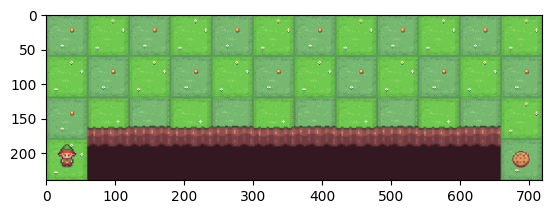

In [27]:
# Our cliffworld has one difference from what's in the image: there is no wall.
# Agent can choose to go as close to the cliff as it wishes.
# x:start, T:exit, C:cliff, o: flat ground

env.reset()
plt.imshow(env.render())
pass

In [28]:
agent_sarsa = EVSarsaAgent(alpha=0.25, epsilon=0.2, discount=0.99,
                           get_legal_actions=lambda s: range(n_actions))

agent_ql = QLearningAgent(alpha=0.25, epsilon=0.2, discount=0.99,
                          get_legal_actions=lambda s: range(n_actions))

EVSARSA mean reward = -28.39
QLEARNING mean reward = -104.81


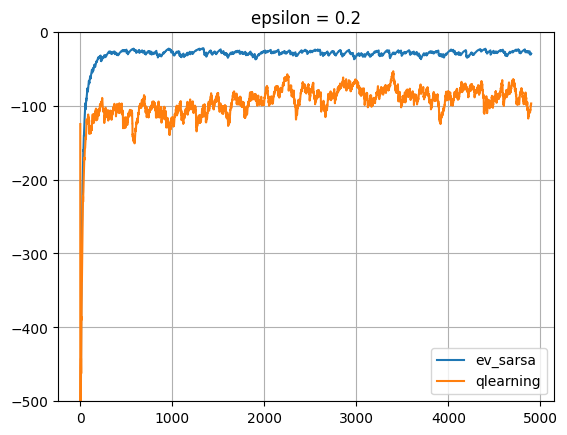

In [29]:
from IPython.display import clear_output
import pandas as pd

def moving_average(x, span=100):
    return pd.DataFrame({'x': np.asarray(x)}).x.ewm(span=span).mean().values

rewards_sarsa, rewards_ql = [], []

for i in range(5000):
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_ql.append(play_and_train(env, agent_ql))
    # Note: agent.epsilon stays constant

    if i % 100 == 0:
        clear_output(True)
        print('EVSARSA mean reward =', np.mean(rewards_sarsa[-100:]))
        print('QLEARNING mean reward =', np.mean(rewards_ql[-100:]))
        plt.title("epsilon = %s" % agent_ql.epsilon)
        plt.plot(moving_average(rewards_sarsa), label='ev_sarsa')
        plt.plot(moving_average(rewards_ql), label='qlearning')
        plt.grid()
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()

Давайте теперь посмотрим, чему научились алгоритмы, визуализируя свои действия в каждом состоянии.

In [30]:
def draw_policy(agent):
    """ Prints CliffWalkingEnv policy with arrows. Hard-coded. """
    
    env = gym.make('CliffWalking-v0', render_mode='ansi')
    env.reset()
    grid = [x.split('  ') for x in env.render().split('\n')[:4]]

    n_rows, n_cols = 4, 12
    start_state_index = 36
    actions = '^>v<'

    for yi in range(n_rows):
        for xi in range(n_cols):
            if grid[yi][xi] == 'C':
                print(" C ", end='')
            elif (yi * n_cols + xi) == start_state_index:
                print(" X ", end='')
            elif (yi * n_cols + xi) == n_rows * n_cols - 1:
                print(" T ", end='')
            else:
                print(" %s " %
                      actions[agent.get_best_action(yi * n_cols + xi)], end='')
        print()

In [31]:
print("Q-Learning")
draw_policy(agent_ql)

print("SARSA")
draw_policy(agent_sarsa)

Q-Learning
 v  v  >  v  v  v  >  >  >  v  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 >  >  >  >  >  >  >  >  >  >  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 
SARSA
 >  >  >  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  >  >  >  >  >  >  >  >  v 
 ^  ^  ^  ^  ^  ^  ^  ^  ^  ^  >  v 
 X  C  C  C  C  C  C  C  C  C  C  T 


## SARSA ожидаемого значения для политики softmax (2 балла)

Внедрите агент, который будет использовать политику softmax для выполнения действия. Не забудьте также использовать softmax при расчете ожидаемого значения для оценки стоимости. Нарисуйте политику агента и посмотрите, отличается ли результат от предыдущих подходов. Кроме того, попробуйте использовать разные температуры ($\tau$) и сравните результаты.

$$ \pi(a_i \mid s) = \operatorname{softmax} \left( \left\{ {Q(s, a_j) \over \tau} \right\}_{j=1}^n \right)_i = {\operatorname{exp} \left( Q(s,a_i) / \tau \right)  \over {\sum_{j}  \operatorname{exp} \left( Q(s,a_j) / \tau  \right)}} $$

In [32]:
class SoftmaxEVSarsaAgent(EVSarsaAgent):
    def __init__(self, alpha, tau, discount, get_legal_actions):
        super().__init__(alpha, None, discount, get_legal_actions)
        assert tau > 0
        self.tau = tau
        
    def get_value(self, state):
        """ 
        Returns V_{pi} for current state under softmax policy:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Hint: all other methods from QLearningAgent are still accessible.
        """
        possible_actions = self.get_legal_actions(state)

        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        q_values = [self.get_qvalue(state, action) for action in possible_actions]
        
        exp_q_values = [math.exp(q_value / self.tau) for q_value in q_values]
        
        sum_exp_q_values = sum(exp_q_values)
        
        softmax_probs = [exp_q / sum_exp_q_values for exp_q in exp_q_values]
        
        value = sum(prob * q_value for prob, q_value in zip(softmax_probs, q_values))
        
        return value
    
    def get_action(self, state):
        """
        Compute the action to take in the current state, including exploration.  
        We should take a random action with probability equaled softmax of q values.
        """
        # Pick Action
        possible_actions = self.get_legal_actions(state)
        action = None

        # If there are no legal actions, return None
        if len(possible_actions) == 0:
            return None

        q_values = [self.get_qvalue(state, action) for action in possible_actions]
        
        exp_q_values = [math.exp(q_value / self.tau) for q_value in q_values]
        
        sum_exp_q_values = sum(exp_q_values)
        
        softmax_probs = [exp_q / sum_exp_q_values for exp_q in exp_q_values]
        
        chosen_action = random.choices(possible_actions, weights=softmax_probs, k=1)[0]
        
        return chosen_action

### Подробнее о SARSA

Вот несколько вещей, которые вы можете сделать, если захотите:

* Поиграйте с epsilon. Узнайте, как меняются политики, если вы устанавливаете для epsilon более высокие или более низкие значения (например, 0,75).
* Реализуйте N-шаговые алгоритмы и TD ($\lambda$): смотрите [книгу Саттона] (http://incompleteideas.net/book/RLbook2020.pdf) главы 7 и 12.
* Используйте эти алгоритмы для тренировки на CartPole в предыдущем / следующем задании на этой неделе.

## Part II: experience replay (2 points)

Существует мощный метод, который вы можете использовать для повышения эффективности выборки для алгоритмов, не связанных с политикой: [спойлер] Повторите опыт :)

Загвоздка в том, что вы можете обучать Q-learning и EV-SARSA на кортежах "<s,a,r,s`>", даже если они не выбраны в соответствии с политикой текущего агента. Итак, вот что мы собираемся сделать:

<img src=https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/exp_replay.png width=480>

#### Тренировка с повторением опыта
1. Поиграйте в игру, попробуйте "<s,a,r,s'>`.
2. Обновите q-значения на основе "<s,a,r,s`>".
3. Сохраните переход "<s,a,r,s`>" в буфере. 
 3. Если буфер заполнен, удалите самые ранние данные.
4. Извлеките K таких переходов из этого буфера и обновите q-значения на их основе.


Чтобы включить такое обучение, сначала мы должны реализовать структуру памяти, которая будет действовать как такой буфер.

In [33]:
from IPython.display import clear_output

In [34]:
import random


class ReplayBuffer(object):
    def __init__(self, size):
        """
        Create Replay buffer.
        Parameters
        ----------
        size: int
            Max number of transitions to store in the buffer. When the buffer
            overflows the old memories are dropped.

        Note: for this assignment you can pick any data structure you want.
              If you want to keep it simple, you can store a list of tuples of (s, a, r, s') in self._storage
              However you may find out there are faster and/or more memory-efficient ways to do so.
        """
        self._storage = []
        self._maxsize = size

        # OPTIONAL: YOUR CODE

    def __len__(self):
        return len(self._storage)

    def add(self, obs_t, action, reward, obs_tp1, done):
        '''
        Make sure, _storage will not exceed _maxsize. 
        Make sure, FIFO rule is being followed: the oldest examples has to be removed earlier
        '''
        data = (obs_t, action, reward, obs_tp1, done)

        # add data to storage
        self._storage.append(data)
        
        if len(self._storage) > self._maxsize:
            self._storage.pop(0)

    def sample(self, batch_size):
        """Sample a batch of experiences.
        Parameters
        ----------
        batch_size: int
            How many transitions to sample.
        Returns
        -------
        obs_batch: np.array
            batch of observations
        act_batch: np.array
            batch of actions executed given obs_batch
        rew_batch: np.array
            rewards received as results of executing act_batch
        next_obs_batch: np.array
            next set of observations seen after executing act_batch
        done_mask: np.array
            done_mask[i] = 1 if executing act_batch[i] resulted in
            the end of an episode and 0 otherwise.
        """
        if batch_size > len(self._storage):
            if len(self._storage) == 0:
                return np.array([]), np.array([]), np.array([]), np.array([]), np.array([])
            
            idxes = [random.randint(0, len(self._storage) - 1) for _ in range(batch_size)]
        else:
            idxes = random.sample(range(len(self._storage)), batch_size)
        
        states, actions, rewards, next_states, dones = [], [], [], [], []
        
        for i in idxes:
            state, action, reward, next_state, done = self._storage[i]
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_state)
            dones.append(done)
        
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards),
            np.array(next_states),
            np.array(dones),
        )

Несколько тестов, чтобы убедиться, что ваш буфер работает правильно

In [35]:
def obj2arrays(obj):
    for x in obj:
        yield np.array([x])

def obj2sampled(obj):
    return tuple(obj2arrays(obj))

replay = ReplayBuffer(2)
obj1 = (0, 1, 2, 3, True)
obj2 = (4, 5, 6, 7, False)
replay.add(*obj1)
assert replay.sample(1) == obj2sampled(obj1), \
    "If there's just one object in buffer, it must be retrieved by buf.sample(1)"
replay.add(*obj2)
assert len(replay) == 2, "Please make sure __len__ methods works as intended."
replay.add(*obj2)
assert len(replay) == 2, "When buffer is at max capacity, replace objects instead of adding new ones."
assert tuple(np.unique(a) for a in replay.sample(100)) == obj2sampled(obj2)
replay.add(*obj1)
assert max(len(np.unique(a)) for a in replay.sample(100)) == 2
replay.add(*obj1)
assert tuple(np.unique(a) for a in replay.sample(100)) == obj2sampled(obj1)
print("Success!")

Success!


Теперь давайте используем этот буфер для улучшения тренировок:

In [36]:
import gymnasium as gym
env = gym.make("Taxi-v3")
n_actions = env.action_space.n

In [37]:
def play_and_train_with_replay(env, agent, replay=None,
                               t_max=10**4, replay_batch_size=32):
    """
    This function should 
    - run a full game, actions given by agent.get_action(s)
    - train agent using agent.update(...) whenever possible
    - return total reward
    :param replay: ReplayBuffer where agent can store and sample (s,a,r,s',done) tuples.
        If None, do not use experience replay
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s
        a = agent.get_action(s)

        next_s, r, done, _, _ = env.step(a)

        # update agent on current transition. Use agent.update
        agent.update(s, a, r, next_s)

        if replay is not None:
            # store current <s,a,r,s'> transition in buffer
            replay.add(s, a, r, next_s, done)

            # sample replay_batch_size random transitions from replay,
            # then update agent on each of them in a loop
            s_, a_, r_, next_s_, done_ = replay.sample(replay_batch_size)
            for i in range(len(s_)):  
                agent.update(s_[i], a_[i], r_[i], next_s_[i])

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

In [38]:
# Create two agents: first will use experience replay, second will not.

agent_baseline = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99,
    get_legal_actions=lambda s: range(n_actions))

agent_replay = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99,
    get_legal_actions=lambda s: range(n_actions))

replay = ReplayBuffer(1000)

Baseline : eps = 2.9191091959171894e-05 mean reward = 8.3
ExpReplay: eps = 2.9191091959171894e-05 mean reward = 7.1


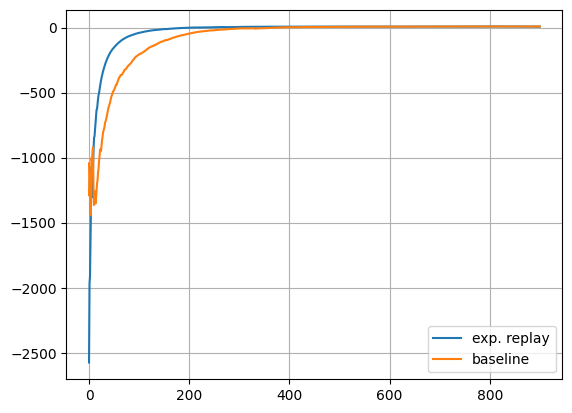

In [39]:
from IPython.display import clear_output
import pandas as pd

def moving_average(x, span=100):
    return pd.DataFrame({'x': np.asarray(x)}).x.ewm(span=span).mean().values

rewards_replay, rewards_baseline = [], []

for i in range(1000):
    rewards_replay.append(
        play_and_train_with_replay(env, agent_replay, replay))
    rewards_baseline.append(
        play_and_train_with_replay(env, agent_baseline, replay=None))

    agent_replay.epsilon *= 0.99
    agent_baseline.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        print('Baseline : eps =', agent_replay.epsilon,
              'mean reward =', np.mean(rewards_baseline[-10:]))
        print('ExpReplay: eps =', agent_baseline.epsilon,
              'mean reward =', np.mean(rewards_replay[-10:]))
        plt.plot(moving_average(rewards_replay), label='exp. replay')
        plt.plot(moving_average(rewards_baseline), label='baseline')
        plt.grid()
        plt.legend()
        plt.show()

#### Чего ожидать:

Повторное использование опыта, при правильной реализации, значительно улучшит начальную сходимость алгоритмов, но не должно повлиять на конечную производительность.

### Заключение

На следующей неделе нашего курса мы будем активно использовать только что написанный вами код. Если вы чувствуете, что вам нужно больше примеров, чтобы понять, как работает воспроизведение опыта, попробуйте использовать его для дискретизированных пространств состояний (CartPole или других __ [классических сред управления](https://gym.openai.com/envs/#classic_control)__).

_На следующей неделе мы рассмотрим, как q-learning и подобные алгоритмы могут быть применены для больших пространств состояний, используя модели глубокого обучения для аппроксимации Q-функции.

Однако код, который вы написали на этой неделе, уже способен решить многие проблемы с RL, и в качестве дополнительного преимущества - его очень легко отсоединить. Вы можете использовать Q-learning, SARSA и Experience Replay для решения любых задач RL, которые хотите решить - просто скопируйте их в файл и импортируйте все, что вам нужно.

### Бонус I: TD($\lambda$) (5+ баллов)

В материалах 3-й недели вы можете ознакомиться с рядом продвинутых алгоритмов (Серебряная лекция II и/или чтение о следах соответствия требованиям). Одним из таких алгоритмов является TD (лямбда), который основан на идее отслеживания соответствия требованиям. Вы также можете рассматривать его как комбинацию N-ступенчатых обновлений для всех N.
* N-ступенчатая временная разница с книгой Саттон - [url] (http://incompleteideas.net/book/the-book-2nd.html), глава 7 (стр. 142 в издании 2020 года)
* Соответствие требованиям из книги Саттон - тот же url, глава 12 (стр. 287)
* Запись в блоге о проверке соответствия требованиям - [url](http://pierrelucbacon.com/traces/)

Вот практический алгоритм, с которого вы можете начать: [url](https://stackoverflow.com/questions/40862578/how-to-understand-watkinss-q%CE%BB-learning-algorithm-in-suttonbartos-rl-book/40892302)


Внедрение этого алгоритма окажется более сложной задачей, чем Q-learning или SARSA, но это позволит вам глубже понять, как работают методы, основанные на ценности [в дополнение к некоторым бонусным баллам].

Больше внимания уделяется сравнению и анализу TD ($\ lambda$) с Q-learning и EV-SARSA в разных настройках (taxi против cartpole, постоянный эпсилон против уменьшающегося эпсилона).

### Бонус II: Еще один pacman (5+ баллов)

__ смотрите README.md в разделе `поисковик и папка pacman`__

ОТКАЗ от ответственности - эта часть сейчас не поддерживается